# Active and Reactive Power Equations

We consider two inverters feeding a common RL load through an inductor. As in the image below: 

![Back to back study](back_to_back.png)


The differential voltage across the inductor is:

$$
V_L = \sqrt{V_1^2 + V_2^2 - 2 V_1 V_2 \cos\theta}
$$

where:

- $ V_1 = \frac{M_1 U_{DC}}{2} $  
- $ V_2 = \frac{M_2 U_{DC}}{2} $  
- $ M_1, M_2 $ = modulation indices (0–1)  
- $ U_{DC} $ = DC link voltage  
- $ \theta $ = phase shift between inverter outputs  

---

## Current in the Inductor
The inductor current magnitude is:

$$
I = \frac{V_L}{Z_{eq}} = \frac{V_L}{\sqrt{R_L^2 + (\omega L)^2}}
$$

where \( R_L \) is the series resistance and \( L \) the inductance.

The **impedance angle** is:

$$
\phi = \tan^{-1}\left(\frac{\omega L}{R_L}\right)
$$

---

## Active Power (P)
The active power delivered by Inverter 1 to the load is:

$$
P = V_1 I \cos(\theta - \phi)
$$

- Depends on modulation \(M_1\), relative angle \(\theta\), and load impedance angle \(\phi\).

---

## Reactive Power (Q)
The reactive power is:

$$
Q = V_1 I \sin(\theta - \phi)
$$

- Positive \(Q\): inductive load behavior  
- Negative \(Q\): capacitive load behavior  

---

## Apparent Power
The complex power is:

$$
S = P + jQ = V_1 I e^{j(\theta - \phi)}
$$

with magnitude:

$$
|S| = V_1 I
$$

---

✅ These equations show how **active and reactive power can be controlled** independently by choosing:
- The ratio $M_1/M_2$ (which sets $V_L$),  
- The phase shift $\theta$,  
- And knowing the load impedance angle $\phi$
- .


# Inductor Sizing Logic (R<sub>L</sub> and L)

We want to size the RL load such that the testbench can explore the **full active power range** and the **full reactive power range** without exceeding the converter limits.

---

## Parameters
- DC link voltage: $U_{DC} = 100 \, \text{V}$
- Peak phase current: $I_{max} = 200 \, \text{A}$
- Frequency: $f = 50 \, \text{Hz}, \quad \omega = 2\pi f \approx 314 \, \text{rad/s}$
- Modulation indices: $M_1, M_2 \in [0,1]$

---

## Case 1: Active Power Sizing ($\theta = 0$)

When the two inverter voltages are in phase:

$$
V_L = \frac{U_{DC}}{2} \, |M_1 - M_2|
$$

The current is:

$$
I = \frac{V_L}{R_L}
$$

Max active power transfer occurs when $M_1 = 1, M_2 = 0$:

$$
R_L = \frac{V_L}{I} = \frac{\tfrac{100}{2}}{200} = 0.25 \, \Omega
$$

---

## Case 2: Reactive Power Sizing ($\theta = \phi$)

For maximum reactive transfer, the inductor dominates the load:

$$
I = \frac{V_L}{\omega L}
$$

Max difference voltage occurs at $M_1 = M_2 = 1, \theta = \pi$:

$$
V_L = U_{DC} = 100 \, \text{V}
$$

Thus:

$$
L = \frac{V_L}{\omega I} = \frac{100}{314 \cdot 200} \approx 1.6 \, \text{mH}
$$

---

## ✅ Final Sizing
- $R_L \approx 0.25 \, \Omega$
- $L \approx 1.6 \, \text{mH}$

These values ensure the converter can explore the **entire active power range** (by setting modulation asymmetry with $\theta=0$) and the **entire reactive range** (by setting $\theta = \phi$) without exceeding the current limit.


# Summary of Power Control and Inductor Sizing Logic

---

## 1. Vector Diagram Basis
We start with the two inverter voltage phasors:

- Inverter 1: amplitude $$V_1 = \frac{M_1 U_{DC}}{2}$$  
- Inverter 2: amplitude $$V_2 = \frac{M_2 U_{DC}}{2}$$  

where:
- $M_1, M_2 \in [0,1]$ are the modulation indices,  
- $U_{DC}$ is the common DC bus voltage,  
- $\theta$ is the phase shift between inverter outputs.  

---

## 2. Voltage Difference Across the Inductor
The inductor sees the voltage difference:

$$
V_L = |\vec{V}_1 - \vec{V}_2| = \frac{U_{DC}}{2} \sqrt{M_1^2 + M_2^2 - 2 M_1 M_2 \cos\theta}
$$

---

## 3. Current Through the RL Load
The load is modeled as:

$$
Z = R_L + j \omega L, 
\quad |Z| = \sqrt{R_L^2 + (\omega L)^2},
\quad \phi = \tan^{-1}\left(\frac{\omega L}{R_L}\right)
$$

The current magnitude is:

$$
I = \frac{V_L}{|Z|}
$$

---

## 4. Active and Reactive Power
The current angle relative to $$V_1$$ is shifted by $$(\theta - \phi)$$.  
Thus, Inverter 1 delivers:

**Active power:**
$$
P = V_1 I \cos(\theta - \phi)
$$

**Reactive power:**
$$
Q = V_1 I \sin(\theta - \phi)
$$

**Apparent power:**
$$
S = V_1 I = \sqrt{P^2 + Q^2}
$$

---

## 5. Power Control Degrees of Freedom
- **Modulation indices** $M_1, M_2$ control the **magnitude of $$V_L$$**, i.e. the current magnitude.  
- **Phase shift** $$\theta$$ controls the **power factor angle**, distributing the power between $$P$$ and $$Q$$.  
- Together, they enable full control of active and reactive power exchange.

---

## 6. Sizing Logic

### Case 1: Maximum Active Power (θ = 0)
Phasors aligned, current aligned with voltage.  
Maximum difference when $$M_1 = 1, M_2 = 0$$:

$$
R_L = \frac{U_{DC}/2}{I_{max}}
$$

Numerical example (UDC = 100 V, Imax = 200 A):

$$
R_L \approx 0.25 \, \Omega
$$

---

### Case 2: Maximum Reactive Power (θ = π, M1 = M2 = 1)
Phasors opposite, maximum differential voltage $$V_L = U_{DC}$$.  
Purely inductive transfer:

$$
L = \frac{U_{DC}}{\omega I_{max}}
$$

Numerical example (UDC = 100 V, Imax = 200 A, f = 50 Hz):

$$
L \approx 1.6 \, \text{mH}
$$

---

## ✅ Final Result
- Equivalent resistance: $$R_L \approx 0.25 \, \Omega$$  
- Inductance: $$L \approx 1.6 \, \text{mH}$$  

This ensures the system can span the **full active power range** (θ = 0, modulation asymmetry) and the **full reactive power range** (θ = π, equal modulation) without exceeding the current limit.


   Frequency [Hz]  Inductance [mH]
0              50         1.591549
1             100         0.795775
2             150         0.530516
3             200         0.397887
4             250         0.318310


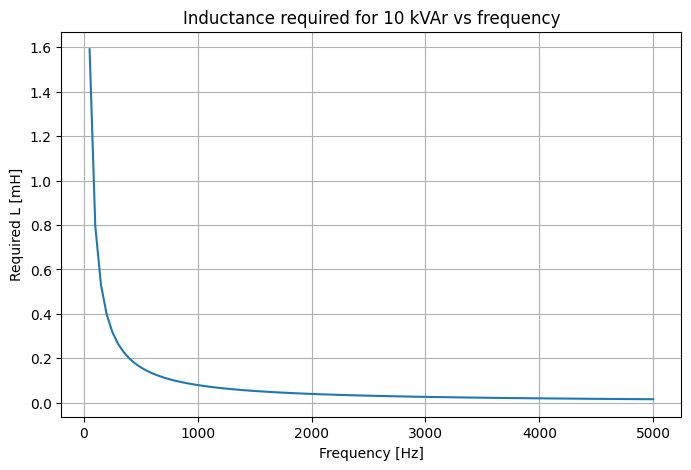

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameters
UDC = 100          # V, DC bus
Q_target = 10e3    # var
Imax = 200         # A (not used here since we want 10kVar)

# From reactive power relation:
# Q = V1 * I, with V1 = UDC/2
# I = Q / V1
# And I = V / (ωL), with V = UDC (worst case difference)
# => L = V / (ω * I)

V1 = UDC/2
I_required = Q_target / V1   # current needed to reach 10kVar

freqs = np.arange(50, 5000+50, 50)
omega = 2*np.pi*freqs

L_values = UDC / (omega * I_required)

# Save results in a DataFrame for display
df = pd.DataFrame({
    "Frequency [Hz]": freqs,
    "Inductance [mH]": L_values*1e3
})

# Show first few lines
print(df.head())

# Plot
plt.figure(figsize=(8,5))
plt.plot(freqs, L_values*1e3)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Required L [mH]")
plt.title("Inductance required for 10 kVAr vs frequency")
plt.grid(True)
plt.show()


Frequency limit where inductor just supports 200 A: 530.5 Hz


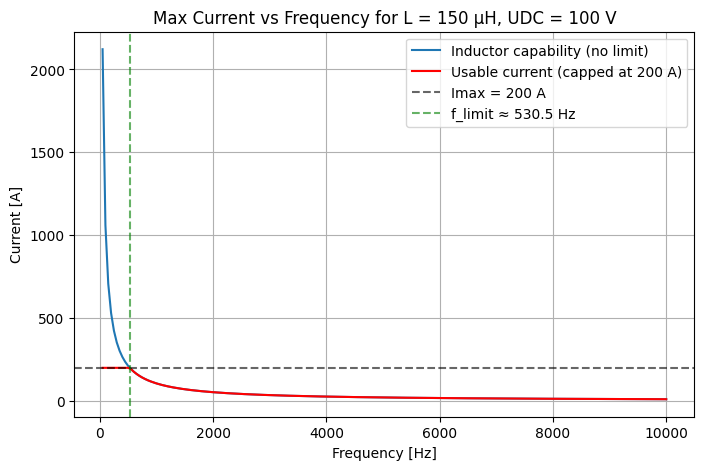

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
UDC = 100        # V, DC link voltage
Imax = 200       # A, peak current per phase
L = 150e-6       # H, chosen inductor
f_min, f_max, f_step = 50, 10000, 50

# Frequency range
freqs = np.arange(f_min, f_max + f_step, f_step)
omega = 2 * np.pi * freqs

# Compute natural current capability for full voltage difference (M1=M2=1, theta=pi)
I_natural = UDC / (omega * L)

# Actual usable current (limited by Imax)
I_usable = np.minimum(I_natural, Imax)

# Frequency limit where inductor current capability == Imax
f_limit = UDC / (2 * np.pi * L * Imax)

# For frequencies below limit, compute max modulation difference (M1-M2)
# At theta=0, VL = (UDC/2)*(M1-M2), and I = VL / R_eq
# For a sine current assumption, R_eq ~ UDC/(2*Imax) so difference can be 1.
# Here we approximate as: (M1-M2)_max = 2*VL/(UDC)
Mdiff_max = np.ones_like(freqs)
Mdiff_max[freqs > f_limit] = I_usable[freqs > f_limit] * (2*L*omega[freqs > f_limit]) / UDC

# Print frequency limit
print(f"Frequency limit where inductor just supports 200 A: {f_limit:.1f} Hz")

# Plot current vs frequency
plt.figure(figsize=(8,5))
plt.plot(freqs, I_natural, label="Inductor capability (no limit)")
plt.plot(freqs, I_usable, 'r', label="Usable current (capped at 200 A)")
plt.axhline(Imax, color='k', linestyle='--', alpha=0.6, label="Imax = 200 A")
plt.axvline(f_limit, color='g', linestyle='--', alpha=0.6, label=f"f_limit ≈ {f_limit:.1f} Hz")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Current [A]")
plt.title(f"Max Current vs Frequency for L = {L*1e6:.0f} µH, UDC = {UDC} V")
plt.legend()
plt.grid(True)
plt.show()


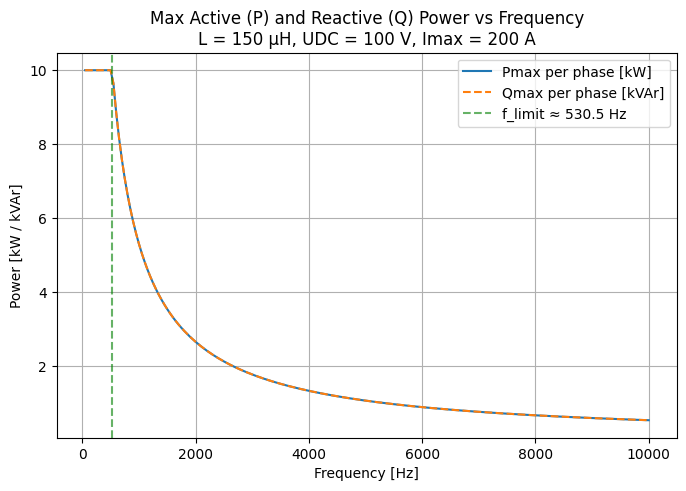

Frequency limit where L current = Imax: 530.5 Hz
At f < 530.5 Hz → Pmax = Qmax ≈ 10.00 kW/kVAr per phase


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
UDC = 100        # V, DC link voltage
Imax = 200       # A, peak current per phase
L = 150e-6       # H, chosen inductor
f_min, f_max, f_step = 50, 10000, 50

# Frequency range
freqs = np.arange(f_min, f_max + f_step, f_step)
omega = 2 * np.pi * freqs

# Natural current capability (worst-case VL = UDC)
I_natural = UDC / (omega * L)

# Usable current capped by Imax
I_usable = np.minimum(I_natural, Imax)

# Frequency limit
f_limit = UDC / (2 * np.pi * L * Imax)

# Max P and Q per phase
V1 = UDC / 2
Pmax = V1 * I_usable   # W
Qmax = V1 * I_usable   # var

# Plot
plt.figure(figsize=(8,5))
plt.plot(freqs, Pmax/1e3, label="Pmax per phase [kW]")
plt.plot(freqs, Qmax/1e3, '--', label="Qmax per phase [kVAr]")
plt.axvline(f_limit, color='g', linestyle='--', alpha=0.6, label=f"f_limit ≈ {f_limit:.1f} Hz")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power [kW / kVAr]")
plt.title(f"Max Active (P) and Reactive (Q) Power vs Frequency\nL = {L*1e6:.0f} µH, UDC = {UDC} V, Imax = {Imax} A")
plt.grid(True)
plt.legend()
plt.show()

print(f"Frequency limit where L current = Imax: {f_limit:.1f} Hz")
print(f"At f < {f_limit:.1f} Hz → Pmax = Qmax ≈ {V1*Imax/1e3:.2f} kW/kVAr per phase")


=== Crossover (inductor-limited) frequency, per config ===
Series x3 : f_limit ≈ 550.0 Hz
Parallel x3: f_limit ≈ 1800.0 Hz


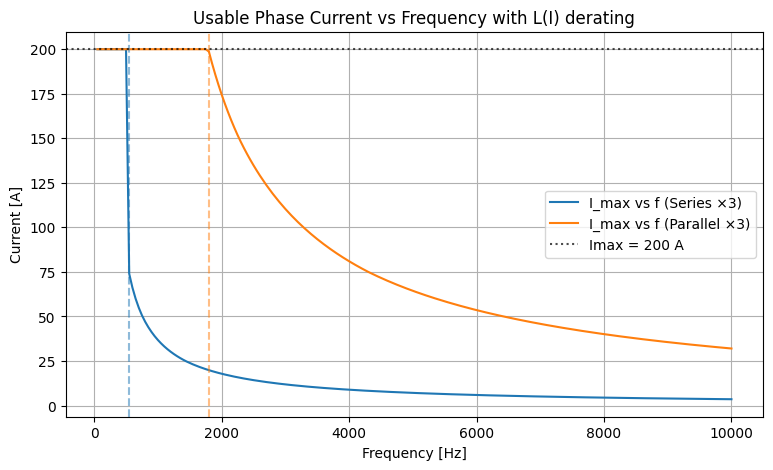

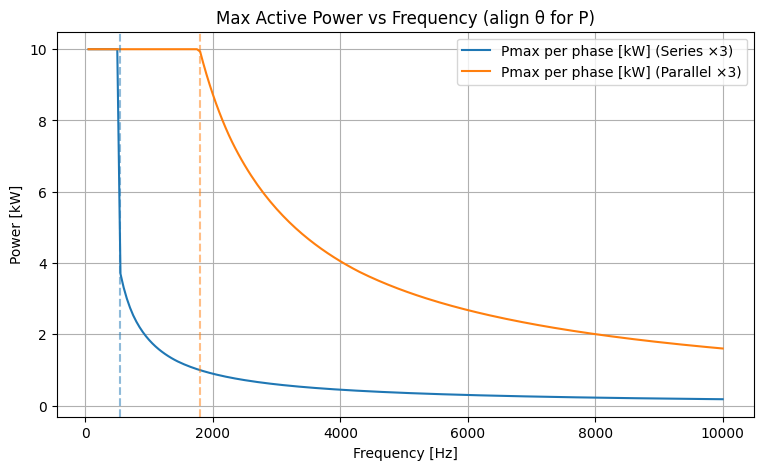

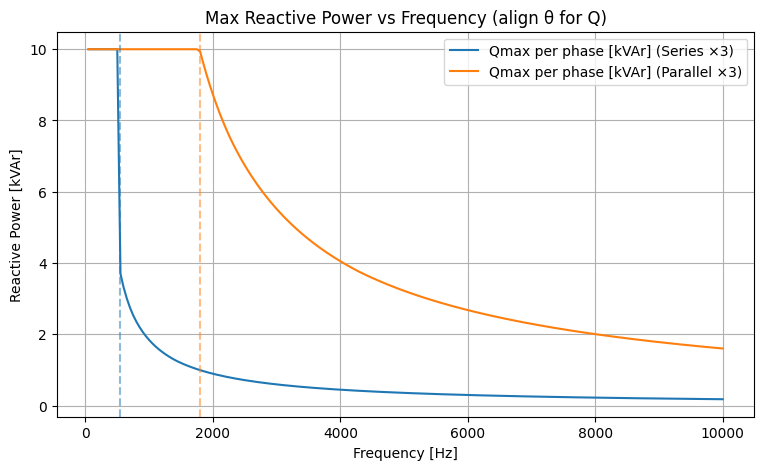

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# User parameters (edit here)
# ----------------------------
UDC   = 100.0     # V, DC link
Imax  = 200.0     # A, peak per phase
fmin, fmax, fstep = 50, 10000, 50  # Hz sweep
# Approximate L(I) from the datasheet curve (µH vs A). Tweak if you have exact points.
# (Current [A], Inductance [µH])
LI_points = np.array([
    [   0, 150],
    [  25, 148],
    [  50, 140],
    [  75, 130],
    [ 100, 100],
    [ 125,  80],
    [ 150,  60],
    [ 175,  50],
    [ 190,  45]
], dtype=float)

# ----------------------------
# Helpers
# ----------------------------
def L_single_uH(I):
    """Piecewise-linear L(I) in microhenry from datasheet points."""
    I_pts  = LI_points[:,0]
    LuH_pts = LI_points[:,1]
    # clamp to end points
    I_clamped = np.clip(I, I_pts.min(), I_pts.max())
    return np.interp(I_clamped, I_pts, LuH_pts)

def solve_current_series(f):
    """
    3 inductors in SERIES per phase:
      L_total(I) = 3 * L_single( I )   (in H)
      Equation: I = min( Imax, UDC / (2π f * L_total(I)) )
    Solve the implicit equation by fixed-point iteration with clamping.
    """
    w = 2*np.pi*f
    I = min(Imax, UDC / (w * (3 * L_single_uH(0)*1e-6)))  # init using zero-current L
    for _ in range(50):
        Ltot = 3 * L_single_uH(I) * 1e-6
        if Ltot <= 0: break
        I_new = UDC / (w * Ltot)
        # enforce current limit
        if I_new > Imax:
            I = Imax
            break
        if abs(I_new - I) < 1e-3:  # A
            I = I_new
            break
        I = 0.6*I + 0.4*I_new
    return min(I, Imax)

def solve_current_parallel(f):
    """
    3 inductors in PARALLEL per phase (identical sharing assumed):
      current per core = I/3
      L_total(I) = L_single(I/3) / 3   (in H)
      Equation: I = min( Imax, UDC / (2π f * L_total(I)) )
    """
    w = 2*np.pi*f
    # init with high-L estimate (use small current)
    I = min(Imax, UDC / (w * ( (L_single_uH(0)*1e-6)/3 )))
    for _ in range(50):
        Ltot = (L_single_uH(I/3.0) * 1e-6) / 3.0
        if Ltot <= 0: break
        I_new = UDC / (w * Ltot)
        if I_new > Imax:
            I = Imax
            break
        if abs(I_new - I) < 1e-3:
            I = I_new
            break
        I = 0.6*I + 0.4*I_new
    return min(I, Imax)

# Sweep
freqs = np.arange(fmin, fmax+fstep, fstep)
I_ser = np.array([solve_current_series(f)   for f in freqs])
I_par = np.array([solve_current_parallel(f) for f in freqs])

# Determine frequency limits (first freq where I falls below Imax)
def first_drop(freqs, I):
    idx = np.where(I < Imax - 1e-6)[0]
    return float(freqs[idx[0]]) if len(idx) else None

f_limit_ser = first_drop(freqs, I_ser)
f_limit_par = first_drop(freqs, I_par)

# Powers per phase (aligning θ for P or Q)
V1 = UDC/2.0
Pmax_ser = V1 * I_ser / 1e3  # kW
Qmax_ser = V1 * I_ser / 1e3  # kVAr
Pmax_par = V1 * I_par / 1e3
Qmax_par = V1 * I_par / 1e3

print("=== Crossover (inductor-limited) frequency, per config ===")
print(f"Series x3 : f_limit ≈ {f_limit_ser:.1f} Hz" if f_limit_ser else "Series x3 : I is Imax up to 10 kHz")
print(f"Parallel x3: f_limit ≈ {f_limit_par:.1f} Hz" if f_limit_par else "Parallel x3: I is Imax up to 10 kHz")

# Plots
plt.figure(figsize=(9,5))
plt.plot(freqs, I_ser,  label="I_max vs f (Series ×3)")
plt.plot(freqs, I_par,  label="I_max vs f (Parallel ×3)")
if f_limit_ser: plt.axvline(f_limit_ser, color='C0', ls='--', alpha=0.5)
if f_limit_par: plt.axvline(f_limit_par, color='C1', ls='--', alpha=0.5)
plt.axhline(Imax, color='k', ls=':', alpha=0.7, label=f"Imax = {Imax:.0f} A")
plt.xlabel("Frequency [Hz]"); plt.ylabel("Current [A]")
plt.title("Usable Phase Current vs Frequency with L(I) derating")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(9,5))
plt.plot(freqs, Pmax_ser,  label="Pmax per phase [kW] (Series ×3)")
plt.plot(freqs, Pmax_par,  label="Pmax per phase [kW] (Parallel ×3)")
if f_limit_ser: plt.axvline(f_limit_ser, color='C0', ls='--', alpha=0.5)
if f_limit_par: plt.axvline(f_limit_par, color='C1', ls='--', alpha=0.5)
plt.xlabel("Frequency [Hz]"); plt.ylabel("Power [kW]")
plt.title("Max Active Power vs Frequency (align θ for P)")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(9,5))
plt.plot(freqs, Qmax_ser,  label="Qmax per phase [kVAr] (Series ×3)")
plt.plot(freqs, Qmax_par,  label="Qmax per phase [kVAr] (Parallel ×3)")
if f_limit_ser: plt.axvline(f_limit_ser, color='C0', ls='--', alpha=0.5)
if f_limit_par: plt.axvline(f_limit_par, color='C1', ls='--', alpha=0.5)
plt.xlabel("Frequency [Hz]"); plt.ylabel("Reactive Power [kVAr]")
plt.title("Max Reactive Power vs Frequency (align θ for Q)")
plt.grid(True); plt.legend(); plt.show()


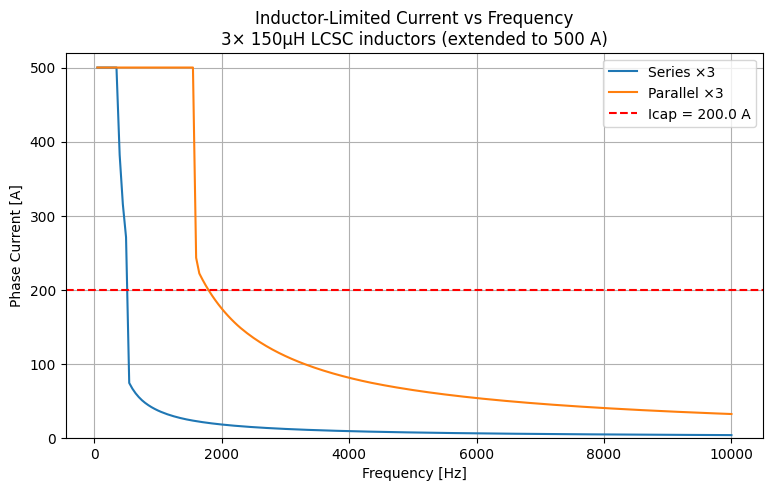

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# User parameters
# ----------------------------
UDC   = 100.0     # V, DC link
Icap  = 200.0     # A, current cap line to trace
fmin, fmax, fstep = 50, 10000, 50  # Hz sweep

# Approximate L(I) from datasheet curve (µH vs A)
LI_points = np.array([
    [   0, 150],
    [  25, 148],
    [  50, 140],
    [  75, 130],
    [ 100, 100],
    [ 125,  80],
    [ 150,  60],
    [ 175,  50],
    [ 190,  45],
    [ 250,  40],
    [ 500,  30]   # extrapolated beyond datasheet for curve extension
], dtype=float)

# ----------------------------
# Helpers
# ----------------------------
def L_single_uH(I):
    """Piecewise-linear L(I) in microhenry"""
    I_pts, L_pts = LI_points[:,0], LI_points[:,1]
    I_clamped = np.clip(I, I_pts.min(), I_pts.max())
    return np.interp(I_clamped, I_pts, L_pts)

def solve_current_series(f):
    """3 inductors in SERIES per phase (self-consistent)"""
    w = 2*np.pi*f
    I = UDC / (w * 3 * L_single_uH(0)*1e-6)  # initial guess
    for _ in range(100):
        Ltot = 3 * L_single_uH(I) * 1e-6
        if Ltot <= 0: break
        I_new = UDC / (w * Ltot)
        if abs(I_new - I) < 1e-3:
            return I_new
        I = 0.6*I + 0.4*I_new
    return I

def solve_current_parallel(f):
    """3 inductors in PARALLEL per phase (equal sharing)"""
    w = 2*np.pi*f
    I = UDC / (w * (L_single_uH(0)*1e-6)/3)  # initial guess
    for _ in range(100):
        Ltot = (L_single_uH(I/3.0) * 1e-6) / 3.0
        if Ltot <= 0: break
        I_new = UDC / (w * Ltot)
        if abs(I_new - I) < 1e-3:
            return I_new
        I = 0.6*I + 0.4*I_new
    return I

# Sweep
freqs = np.arange(fmin, fmax+fstep, fstep)
I_ser = np.array([solve_current_series(f)   for f in freqs])
I_par = np.array([solve_current_parallel(f) for f in freqs])

# Cap at 500 A just for plotting axis
I_ser = np.clip(I_ser, 0, 500)
I_par = np.clip(I_par, 0, 500)

# Plot current vs frequency
plt.figure(figsize=(9,5))
plt.plot(freqs, I_ser, label="Series ×3")
plt.plot(freqs, I_par, label="Parallel ×3")
plt.axhline(Icap, color='r', ls='--', lw=1.5, label=f"Icap = {Icap} A")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Phase Current [A]")
plt.title("Inductor-Limited Current vs Frequency\n3× 150µH LCSC inductors (extended to 500 A)")
plt.ylim(0, 520)
plt.grid(True)
plt.legend()
plt.show()


# Summary of Power Control and Inductor Sizing Logic (Extended)

---

## 1. What It Is: Opposition Inverter Setup
Two inverters share the same DC bus and oppose each other through a coupling inductor.  
By adjusting the **modulation indices** ($M_1, M_2$) and the **phase shift** ($\theta$), we control the **voltage difference** across the inductor and therefore the **active and reactive power** exchanged.

---

## 2. Vector Diagram Basis
Each inverter produces a voltage phasor:

- Inverter 1: $$V_1 = \tfrac{M_1 U_{DC}}{2}$$  
- Inverter 2: $$V_2 = \tfrac{M_2 U_{DC}}{2}$$  

where:
- $M_1, M_2 \in [0,1]$ are modulation indices  
- $U_{DC}$ is the DC bus voltage  
- $\theta$ is the phase shift between inverters  

---

## 3. Inductor Voltage
The voltage difference across the inductor is:

$$
V_L = |\vec{V}_1 - \vec{V}_2| 
= \frac{U_{DC}}{2} \sqrt{M_1^2 + M_2^2 - 2 M_1 M_2 \cos\theta}
$$

---

## 4. Current Through RL Impedance
The inductor is not ideal; it has parasitic resistance:

$$
Z = R_L + j \omega L, \quad 
|Z| = \sqrt{R_L^2 + (\omega L)^2}, \quad 
\phi = \tan^{-1}\!\Big(\frac{\omega L}{R_L}\Big)
$$

Current magnitude:

$$
I = \frac{V_L}{|Z|}
$$

- $\phi$ is the **load angle**: less than $90^\circ$ because of $R_L$.  
- This must be **compensated in control**: to get purely reactive transfer, $\theta$ must be offset by $\phi$.  

---

## 5. Active and Reactive Power
Relative to inverter 1:

- **Active power:**
$$
P = V_1 I \cos(\theta - \phi)
$$

- **Reactive power:**
$$
Q = V_1 I \sin(\theta - \phi)
$$

- **Apparent power:**
$$
S = V_1 I = \sqrt{P^2 + Q^2}
$$

---

## 6. Power Control Degrees of Freedom
- $M_1, M_2$ control the **magnitude of $V_L$**, hence the current magnitude.  
- $\theta$ shifts the power factor angle, controlling the $P/Q$ split.  
- Together, these allow **independent control of P and Q** over a wide range.  

---

## 7. Ideal Sizing Logic (No Derating)

- **Max Active Power (θ = 0, M1 = 1, M2 = 0):**

$$
R_L = \frac{U_{DC}/2}{I_{max}}
$$

For $U_{DC}=100$ V, $I_{max}=200$ A:

$$
R_L \approx 0.25 \, \Omega
$$

- **Max Reactive Power (θ = π, M1 = M2 = 1):**

$$
L = \frac{U_{DC}}{\omega I_{max}}
$$

At 50 Hz:

$$
L \approx 1.6 \, \text{mH}
$$

---

## 8. Real Inductor Behavior (150 µH part from LCSC)

The chosen inductor **is nonlinear**: its inductance $L(I)$ decreases with current (saturation).  
Datasheet curve shows:

- $L \approx 150 \, \mu$H at small current  
- dropping toward $50 \, \mu$H near $200$ A  

This means the effective impedance reduces at high current, which **raises current ripple and lowers frequency limit**.

---

## 9. Series vs Parallel Configurations

- **3× Series per phase**  
  - Total inductance: $$L_{tot} = 3 L(I)$$  
  - Each inductor carries **full phase current**  
  - Better for low-frequency stability, but stronger derating (since each core saturates).

- **3× Parallel per phase**  
  - Total inductance: $$L_{tot} = L(I/3) / 3$$  
  - Current splits, each core sees only $I/3$  
  - Weaker total inductance, but stays in higher-$L$ region at high current → better high-frequency capability.

---

## 10. Frequency Limits

The usable current is:

$$
I(f) = \min\!\left(I_{max}, \; \frac{U_{DC}}{2 \pi f L_{tot}(I)} \right)
$$

- **Below crossover frequency**: Current is limited by $I_{max}$ (200 A).  
- **Above crossover frequency**: Inductor impedance dominates, current falls $\propto 1/f$.  
- With derating, the crossover shifts depending on configuration (series vs parallel).  

---

## 11. Final Picture

- With **ideal L ≈ 1.6 mH**, you could span full $P/Q$ range at 50 Hz.  
- With the **real 150 µH inductor**:  
  - You still reach $\approx 10$ kW / 10 kVAr per phase below a few hundred Hz.  
  - Above that, capability drops with frequency.  
  - Parallel connection offers better high-frequency performance due to reduced saturation per core.  

---

## 12. Inductor Derating Curve

*(Insert datasheet curve image here for $L(I)$, as a reminder of inductance vs current)*

---

## ✅ Takeaway
- The simple phasor equations explain **how modulation and phase shift control power**.  
- Sizing equations set the **ideal R and L**.  
- Real inductors **derate with current**: actual $P/Q$ limits vs frequency depend on $L(I)$.  
- Using multiple inductors (series or parallel) trades off low-f vs high-f performance.  


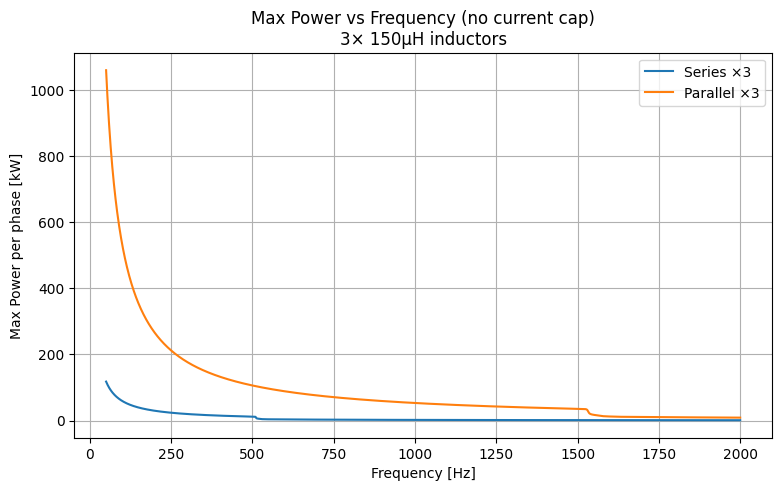

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
UDC = 100.0               # V
f_min, f_max, f_step = 50, 2000, 1
freqs = np.arange(f_min, f_max+f_step, f_step)

# Approximate L(I) curve from datasheet [A, µH]
LI_points = np.array([
    [   0, 150],
    [  25, 148],
    [  50, 140],
    [  75, 130],
    [ 100, 100],
    [ 125,  80],
    [ 150,  60],
    [ 175,  50],
    [ 190,  45]
], dtype=float)

def L_single_uH(I):
    """Piecewise-linear interpolation of L(I) in µH"""
    I_pts, L_pts = LI_points[:,0], LI_points[:,1]
    I_clamped = np.clip(I, I_pts.min(), I_pts.max())
    return np.interp(I_clamped, I_pts, L_pts)

def solve_current_series(f):
    """3 inductors in SERIES per phase"""
    w = 2*np.pi*f
    I = UDC / (w * 3 * L_single_uH(0)*1e-6)  # init guess
    for _ in range(50):
        Ltot = 3 * L_single_uH(I) * 1e-6
        if Ltot <= 0: break
        I_new = UDC / (w * Ltot)
        if abs(I_new - I) < 1e-3:
            return I_new
        I = 0.6*I + 0.4*I_new
    return I

def solve_current_parallel(f):
    """3 inductors in PARALLEL per phase (equal current sharing)"""
    w = 2*np.pi*f
    I = UDC / (w * (L_single_uH(0)*1e-6)/3)  # init guess
    for _ in range(50):
        Ltot = (L_single_uH(I/3.0) * 1e-6) / 3.0
        if Ltot <= 0: break
        I_new = UDC / (w * Ltot)
        if abs(I_new - I) < 1e-3:
            return I_new
        I = 0.6*I + 0.4*I_new
    return I

# Sweep
I_ser = np.array([solve_current_series(f)   for f in freqs])
I_par = np.array([solve_current_parallel(f) for f in freqs])

# Power per phase (P=Q in magnitude when aligned for active/reactive)
V1 = UDC/2
P_ser = V1 * I_ser / 1e3  # kW
P_par = V1 * I_par / 1e3  # kW

# Plot
plt.figure(figsize=(9,5))
plt.plot(freqs, P_ser, label="Series ×3")
plt.plot(freqs, P_par, label="Parallel ×3")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Max Power per phase [kW]")
plt.title("Max Power vs Frequency (no current cap)\n3× 150µH inductors")
plt.grid(True)
plt.legend()
plt.show()


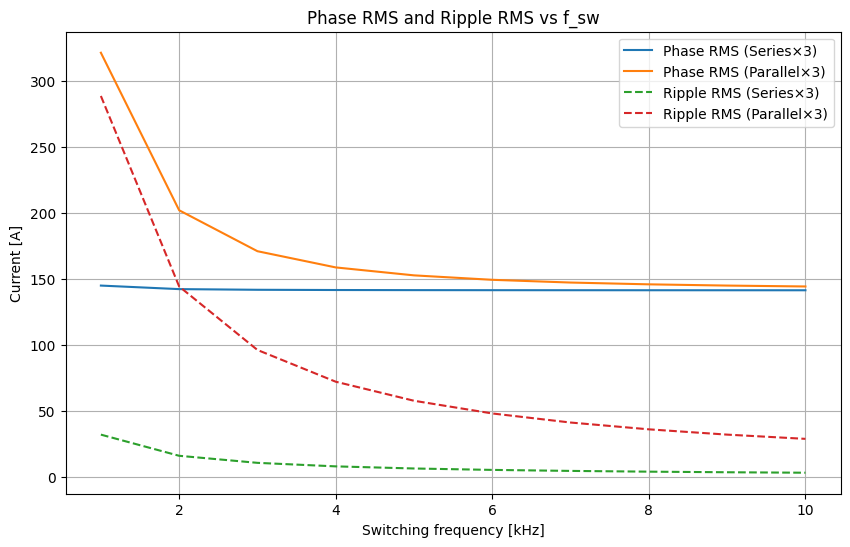

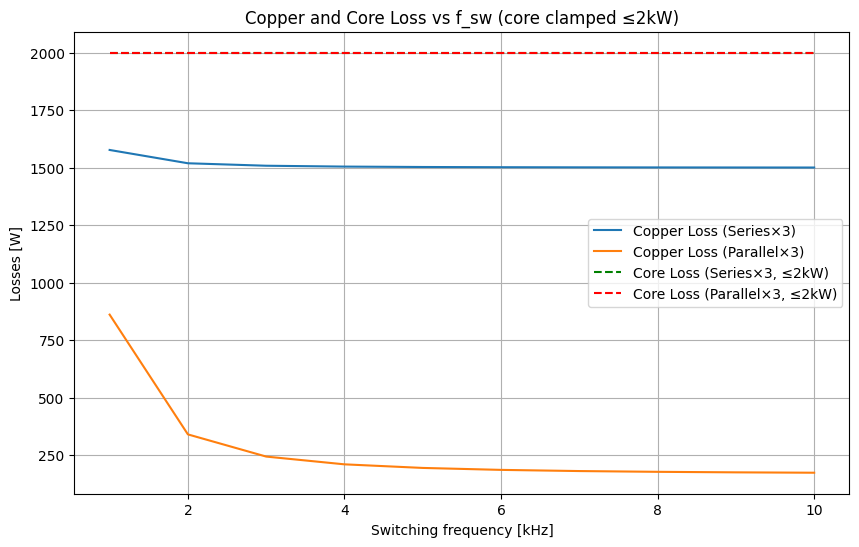

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# User parameters
# ----------------------------
UDC   = 100.0      # V DC bus
I_fund = 200.0     # A peak fundamental
f_sw_range = np.linspace(1e3, 10e3, 10)   # 5 kHz → 300 kHz sweep

# Inductor parameters (per core)
L_nom = 150e-6     # H
R_nom = 25e-3      # Ohm
core_k = 1e-6      # Core loss coefficient (tuned down)
core_alpha = 1.3   # Frequency exponent
core_beta  = 2.0   # Flux swing exponent

# Ripple voltage amplitude
V_ripple = UDC

# ----------------------------
# Helper functions
# ----------------------------
def ripple_pp(Ltot, f_sw):
    return V_ripple / (2 * Ltot * f_sw)

def ripple_rms(dIpp):
    return dIpp / (2*np.sqrt(3))

def copper_loss(Rtot, I_fund, Ir_rms):
    I_rms = np.sqrt((I_fund/np.sqrt(2))**2 + Ir_rms**2)
    return Rtot * I_rms**2, I_rms

def core_loss(dIpp, Ltot, f_sw):
    # ΔB ∝ ΔI/L
    return core_k * (f_sw**core_alpha) * (dIpp/Ltot)**core_beta

# ----------------------------
# Sweep over f_sw
# ----------------------------
Ir_rms_ser, Ir_rms_par = [], []
I_rms_ser,  I_rms_par  = [], []
Pcu_ser,    Pcu_par    = [], []
Pcore_ser,  Pcore_par  = [], []

for f_sw in f_sw_range:
    # Series ×3
    L_ser, R_ser = 3*L_nom, 3*R_nom
    dI_ser = ripple_pp(L_ser, f_sw)
    Ir_ser = ripple_rms(dI_ser)
    Pcu_s, Irms_s = copper_loss(R_ser, I_fund, Ir_ser)
    Pcore_s = core_loss(dI_ser, L_ser, f_sw)
    Ir_rms_ser.append(Ir_ser); I_rms_ser.append(Irms_s)
    Pcu_ser.append(Pcu_s); Pcore_ser.append(min(Pcore_s, 2000))  # clamp at 2 kW
    
    # Parallel ×3
    L_par, R_par = L_nom/3, R_nom/3
    dI_par = ripple_pp(L_par, f_sw)
    Ir_par = ripple_rms(dI_par)
    Pcu_p, Irms_p = copper_loss(R_par, I_fund, Ir_par)
    Pcore_p = core_loss(dI_par, L_par, f_sw)
    Ir_rms_par.append(Ir_par); I_rms_par.append(Irms_p)
    Pcu_par.append(Pcu_p); Pcore_par.append(min(Pcore_p, 2000))

# Convert to arrays
Ir_rms_ser, Ir_rms_par = np.array(Ir_rms_ser), np.array(Ir_rms_par)
I_rms_ser,  I_rms_par  = np.array(I_rms_ser),  np.array(I_rms_par)
Pcu_ser,    Pcu_par    = np.array(Pcu_ser),    np.array(Pcu_par)
Pcore_ser,  Pcore_par  = np.array(Pcore_ser),  np.array(Pcore_par)

# ----------------------------
# Aggregated plots
# ----------------------------

# Currents
plt.figure(figsize=(10,6))
plt.plot(f_sw_range/1e3, I_rms_ser,  label="Phase RMS (Series×3)")
plt.plot(f_sw_range/1e3, I_rms_par,  label="Phase RMS (Parallel×3)")
plt.plot(f_sw_range/1e3, Ir_rms_ser, '--', label="Ripple RMS (Series×3)")
plt.plot(f_sw_range/1e3, Ir_rms_par, '--', label="Ripple RMS (Parallel×3)")
plt.xlabel("Switching frequency [kHz]")
plt.ylabel("Current [A]")
plt.title("Phase RMS and Ripple RMS vs f_sw")
plt.grid(True); plt.legend()
plt.show()

# Losses
plt.figure(figsize=(10,6))
plt.plot(f_sw_range/1e3, Pcu_ser,  label="Copper Loss (Series×3)")
plt.plot(f_sw_range/1e3, Pcu_par,  label="Copper Loss (Parallel×3)")
plt.plot(f_sw_range/1e3, Pcore_ser, '--g', label="Core Loss (Series×3, ≤2kW)")
plt.plot(f_sw_range/1e3, Pcore_par, '--r', label="Core Loss (Parallel×3, ≤2kW)")
plt.xlabel("Switching frequency [kHz]")
plt.ylabel("Losses [W]")
plt.title("Copper and Core Loss vs f_sw (core clamped ≤2kW)")
plt.grid(True); plt.legend()
plt.show()


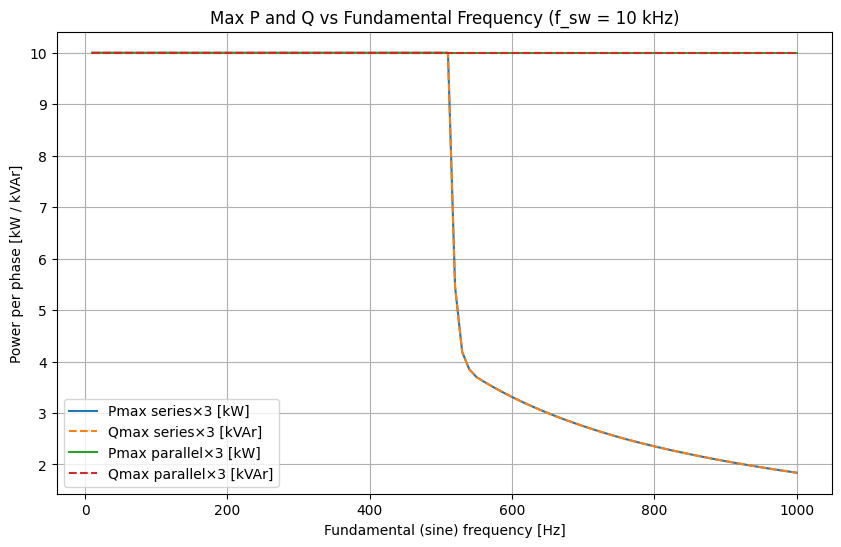

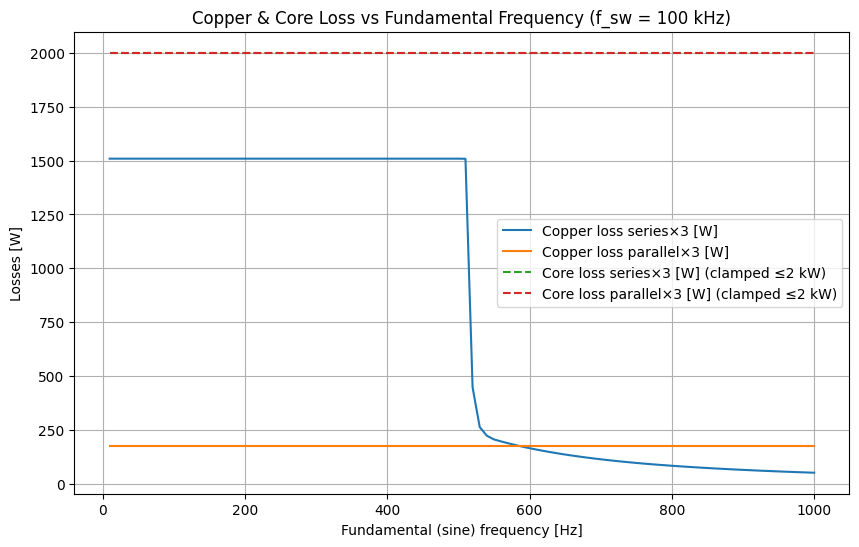

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Fixed test parameters
# ----------------------------
UDC    = 100.0        # V DC link
V1     = UDC/2.0      # fundamental amplitude of inverter 1
Icap   = 200.0        # A peak phase current limit (edit if needed)
f_sw   = 10e3        # Hz switching frequency (fixed as requested)
f_min, f_max, f_step = 10, 1000, 10   # Hz sweep of fundamental (sine) frequency

# LCSC 150 uH inductor (C37634000): L(I) approximated from datasheet curve (µH vs A)
LI_points = np.array([
    [   0, 150],
    [  25, 148],
    [  50, 140],
    [  75, 130],
    [ 100, 100],
    [ 125,  80],
    [ 150,  60],
    [ 175,  50],
    [ 190,  45]
], dtype=float)

# DC resistance per core (datasheet ~25 mΩ)
R_core = 25e-3  # Ohm

# Simple core-loss model coefficients (tune to your core material if you have curves)
core_k     = 1e-6
core_alpha = 1.3
core_beta  = 2.0

# ----------------------------
# Helper functions
# ----------------------------
def L_single_uH(I):
    """Piecewise-linear interpolation of L(I) in µH (datasheet)."""
    I_pts, L_pts = LI_points[:,0], LI_points[:,1]
    I_clamped = np.clip(I, I_pts.min(), I_pts.max())
    return np.interp(I_clamped, I_pts, L_pts)

def solve_current_series(ff):
    """
    Opposition test at fundamental freq ff.
    Max differential voltage VL = UDC (theta = pi, M1 = M2 = 1).
    Series: L_tot(I) = 3*L(I), R_tot = 3*R_core.
    Solve I = min(Icap, UDC / (omega * L_tot(I))).
    """
    w = 2*np.pi*ff
    I = min(Icap, UDC / (w * 3 * L_single_uH(0)*1e-6))  # initial guess
    for _ in range(60):
        Ltot = 3 * L_single_uH(I) * 1e-6
        if Ltot <= 0: break
        I_new = UDC / (w * Ltot)
        I_new = min(I_new, Icap)
        if abs(I_new - I) < 1e-3:
            I = I_new
            break
        I = 0.6*I + 0.4*I_new
    Ltot = 3 * L_single_uH(I) * 1e-6
    Rtot = 3 * R_core
    return I, Ltot, Rtot

def solve_current_parallel(ff):
    """
    Parallel: three identical cores in parallel.
    Each core sees I/3, so L_tot(I) = L(I/3) / 3, R_tot = R_core/3.
    Solve I self-consistently.
    """
    w = 2*np.pi*ff
    I = min(Icap, UDC / (w * (L_single_uH(0)*1e-6)/3))  # initial guess
    for _ in range(60):
        Ltot = (L_single_uH(I/3.0)*1e-6)/3.0
        if Ltot <= 0: break
        I_new = UDC / (w * Ltot)
        I_new = min(I_new, Icap)
        if abs(I_new - I) < 1e-3:
            I = I_new
            break
        I = 0.6*I + 0.4*I_new
    Ltot = (L_single_uH(I/3.0)*1e-6)/3.0
    Rtot = R_core/3.0
    return I, Ltot, Rtot

def ripple_pp(Ltot):
    """Peak-to-peak HF ripple for PWM at f_sw with approx step ~ UDC."""
    return UDC / (2 * Ltot * f_sw)

def ripple_rms(dIpp):
    """RMS of triangular ripple."""
    return dIpp / (2*np.sqrt(3))

def copper_loss(Rtot, I_peak, Ir_rms):
    """Copper loss using total RMS = sqrt(Ifund_rms^2 + Iripple_rms^2)."""
    Ifund_rms = I_peak / np.sqrt(2)
    I_rms = np.sqrt(Ifund_rms**2 + Ir_rms**2)
    return Rtot * I_rms**2, I_rms

def core_loss(dIpp, Ltot):
    """
    Very simple Steinmetz-style proxy:
    P_core ∝ f_sw^alpha * (ΔI/L)^beta
    (Units are scaled by core_k; treat as relative unless you fit to material data.)
    """
    return core_k * (f_sw**core_alpha) * (dIpp / Ltot)**core_beta

# ----------------------------
# Sweep fundamental frequency
# ----------------------------
freqs = np.arange(f_min, f_max+f_step, f_step)

P_ser, Q_ser, Pcu_ser, Pcore_ser = [], [], [], []
P_par, Q_par, Pcu_par, Pcore_par = [], [], [], []

for ff in freqs:
    # Series
    I_ser, L_ser, R_ser = solve_current_series(ff)
    dIpp_ser = ripple_pp(L_ser)
    Irms_rip_ser = ripple_rms(dIpp_ser)
    Pcu_s, I_rms_s = copper_loss(R_ser, I_ser, Irms_rip_ser)
    Pcore_s = core_loss(dIpp_ser, L_ser)
    # Max P or Q (align theta for active or reactive)
    Pmax_s = V1 * min(I_ser, Icap)
    Qmax_s = V1 * min(I_ser, Icap)
    P_ser.append(Pmax_s/1e3); Q_ser.append(Qmax_s/1e3)
    Pcu_ser.append(Pcu_s);    Pcore_ser.append(Pcore_s)

    # Parallel
    I_par, L_par, R_par = solve_current_parallel(ff)
    dIpp_par = ripple_pp(L_par)
    Irms_rip_par = ripple_rms(dIpp_par)
    Pcu_p, I_rms_p = copper_loss(R_par, I_par, Irms_rip_par)
    Pcore_p = core_loss(dIpp_par, L_par)
    Pmax_p = V1 * min(I_par, Icap)
    Qmax_p = V1 * min(I_par, Icap)
    P_par.append(Pmax_p/1e3); Q_par.append(Qmax_p/1e3)
    Pcu_par.append(Pcu_p);    Pcore_par.append(Pcore_p)

P_ser  = np.array(P_ser);  Q_ser  = np.array(Q_ser)
P_par  = np.array(P_par);  Q_par  = np.array(Q_par)
Pcu_ser= np.array(Pcu_ser);Pcu_par= np.array(Pcu_par)
Pcore_ser = np.array(Pcore_ser); Pcore_par = np.array(Pcore_par)

# ----------------------------
# Plots
# ----------------------------

# P and Q (per phase)
plt.figure(figsize=(10,6))
plt.plot(freqs, P_ser, label="Pmax series×3 [kW]")
plt.plot(freqs, Q_ser, '--', label="Qmax series×3 [kVAr]")
plt.plot(freqs, P_par, label="Pmax parallel×3 [kW]")
plt.plot(freqs, Q_par, '--', label="Qmax parallel×3 [kVAr]")
plt.xlabel("Fundamental (sine) frequency [Hz]")
plt.ylabel("Power per phase [kW / kVAr]")
plt.title("Max P and Q vs Fundamental Frequency (f_sw = 10 kHz)")
plt.grid(True); plt.legend()
plt.show()

# Losses
plt.figure(figsize=(10,6))
plt.plot(freqs, Pcu_ser,  label="Copper loss series×3 [W]")
plt.plot(freqs, Pcu_par,  label="Copper loss parallel×3 [W]")
plt.plot(freqs, np.minimum(Pcore_ser, 2000), '--', label="Core loss series×3 [W] (clamped ≤2 kW)")
plt.plot(freqs, np.minimum(Pcore_par, 2000), '--', label="Core loss parallel×3 [W] (clamped ≤2 kW)")
plt.xlabel("Fundamental (sine) frequency [Hz]")
plt.ylabel("Losses [W]")
plt.title("Copper & Core Loss vs Fundamental Frequency (f_sw = 100 kHz)")
plt.grid(True); plt.legend()
plt.show()


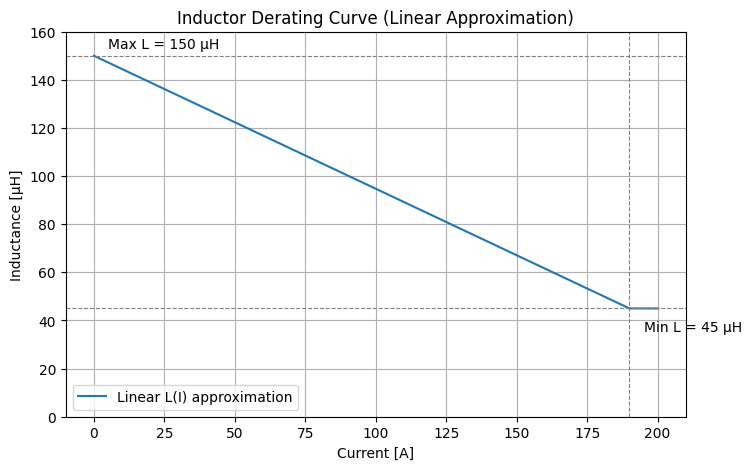

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Approximation parameters (from datasheet curve)
L0 = 150.0   # µH at light current
Lmin = 45.0  # µH at ~190 A
Imax_data = 190.0  # A, current at which Lmin is reached

# slope of linear derating
k = (L0 - Lmin) / Imax_data  # µH per A

# Current sweep
I = np.linspace(0, 200, 500)  # 0–200 A
L = np.clip(L0 - k*I, Lmin, L0)

# Plot
plt.figure(figsize=(8,5))
plt.plot(I, L, label="Linear L(I) approximation")
plt.axhline(L0, color='gray', ls='--', lw=0.8)
plt.axhline(Lmin, color='gray', ls='--', lw=0.8)
plt.axvline(Imax_data, color='gray', ls='--', lw=0.8)

# Annotations
plt.text(5, L0+2, f"Max L = {L0:.0f} µH", color='black', va='bottom')
plt.text(Imax_data+5, Lmin-5, f"Min L = {Lmin:.0f} µH", color='black', va='top')

plt.title("Inductor Derating Curve (Linear Approximation)")
plt.xlabel("Current [A]")
plt.ylabel("Inductance [µH]")
plt.ylim(0,160)
plt.grid(True)
plt.legend()
plt.show()


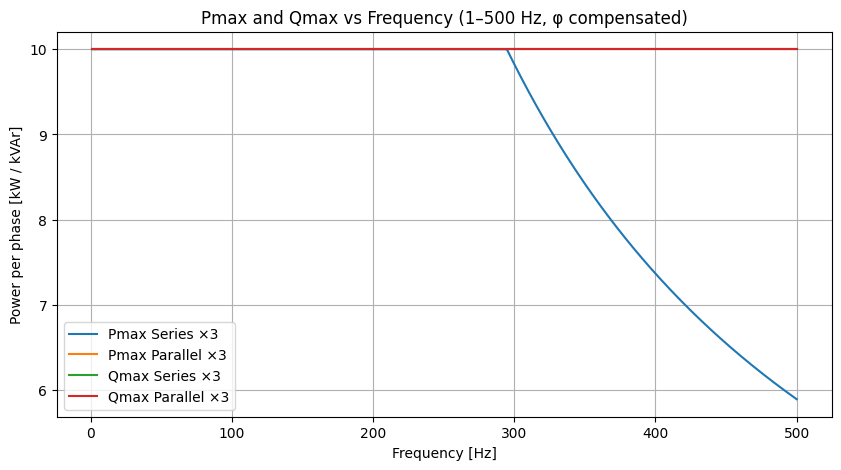

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Parameters
# ----------------------------
UDC = 100.0     # DC bus voltage [V]
Imax = 200.0    # max peak phase current [A]
f_range = np.arange(1, 501, 1)  # 1–500 Hz

# Inductor derating parameters (linear approx from datasheet)
L0 = 150.0   # µH
Lmin = 45.0  # µH
Imax_data = 190.0  # A
k = (L0 - Lmin) / Imax_data  # µH per A

def L_single(I):
    """Single core inductance [H] vs current [A], linear model"""
    L_uH = np.clip(L0 - k*I, Lmin, L0)
    return L_uH * 1e-6

# ----------------------------
# Effective inductances for series/parallel (at Imax)
# ----------------------------
def L_series(I):   # 3 in series
    return 3 * L_single(I)

def L_parallel(I): # 3 in parallel (current splits evenly)
    return L_single(I/3) / 3

# ----------------------------
# Compute I, Pmax, Qmax vs frequency
# ----------------------------
def compute_limits(L_func):
    I_reac = []
    I_act = []
    for f in f_range:
        w = 2*np.pi*f
        # Conservative: evaluate L at Imax
        Ltot = L_func(Imax)
        # Inductor-limited currents
        I_reac_L = UDC / (w * Ltot)
        I_act_L  = (UDC/2) / (w * Ltot)
        # Apply clamp
        I_reac.append(min(Imax, I_reac_L))
        I_act.append(min(Imax, I_act_L))
    I_reac = np.array(I_reac)
    I_act = np.array(I_act)
    # Powers per phase
    V1 = UDC/2
    Pmax = V1 * I_act / 1000.0  # kW
    Qmax = V1 * I_reac / 1000.0 # kVAr
    return Pmax, Qmax

P_ser, Q_ser = compute_limits(L_series)
P_par, Q_par = compute_limits(L_parallel)

# ----------------------------
# Plot results
# ----------------------------
plt.figure(figsize=(10,5))
plt.plot(f_range, P_ser, label="Pmax Series ×3")
plt.plot(f_range, P_par, label="Pmax Parallel ×3")
plt.plot(f_range, Q_ser, label="Qmax Series ×3")
plt.plot(f_range, Q_par, label="Qmax Parallel ×3")
plt.title("Pmax and Qmax vs Frequency (1–500 Hz, φ compensated)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power per phase [kW / kVAr]")
plt.grid(True)
plt.legend()
plt.show()


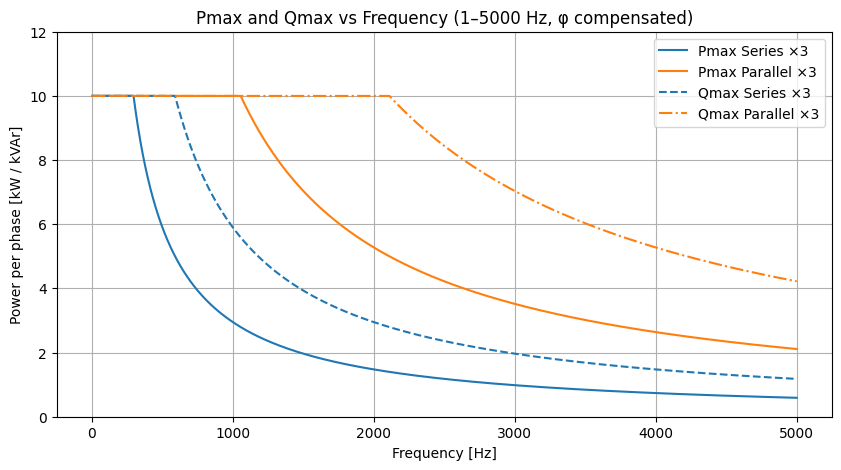

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Parameters
# ----------------------------
UDC = 100.0     # DC bus voltage [V]
Imax = 200.0    # max peak phase current [A]
f_range = np.arange(1, 5000, 1)  # 1–500 Hz

# Inductor derating parameters (linear approx from datasheet)
L0 = 150.0   # µH
Lmin = 45.0  # µH
Imax_data = 190.0  # A
k = (L0 - Lmin) / Imax_data  # µH per A

def L_single(I):
    """Single core inductance [H] vs current [A], linear model"""
    L_uH = np.clip(L0 - k*I, Lmin, L0)
    return L_uH * 1e-6

# ----------------------------
# Effective inductances for series/parallel (at Imax)
# ----------------------------
def L_series(I):   # 3 in series
    return 3 * L_single(I)

def L_parallel(I): # 3 in parallel (current splits evenly)
    return L_single(I/3) / 3

# ----------------------------
# Compute I, Pmax, Qmax vs frequency
# ----------------------------
def compute_limits(L_func):
    I_reac = []
    I_act = []
    for f in f_range:
        w = 2*np.pi*f
        # Conservative: evaluate L at Imax
        Ltot = L_func(Imax)
        # Inductor-limited currents
        I_reac_L = UDC / (w * Ltot)
        I_act_L  = (UDC/2) / (w * Ltot)
        # Apply clamp
        I_reac.append(min(Imax, I_reac_L))
        I_act.append(min(Imax, I_act_L))
    I_reac = np.array(I_reac)
    I_act = np.array(I_act)
    # Powers per phase
    V1 = UDC/2
    Pmax = V1 * I_act / 1000.0  # kW
    Qmax = V1 * I_reac / 1000.0 # kVAr
    return Pmax, Qmax

P_ser, Q_ser = compute_limits(L_series)
P_par, Q_par = compute_limits(L_parallel)

# ----------------------------
# Plot results
# ----------------------------
plt.figure(figsize=(10,5))
plt.plot(f_range, P_ser, label="Pmax Series ×3", color="C0")
plt.plot(f_range, P_par, label="Pmax Parallel ×3", color="C1")
plt.plot(f_range, Q_ser, '--', label="Qmax Series ×3", color="C0")
plt.plot(f_range, Q_par, '-.', label="Qmax Parallel ×3", color="C1")

plt.title("Pmax and Qmax vs Frequency (1–5000 Hz, φ compensated)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power per phase [kW / kVAr]")
plt.grid(True)
plt.legend()
plt.ylim(0,12)
plt.show()


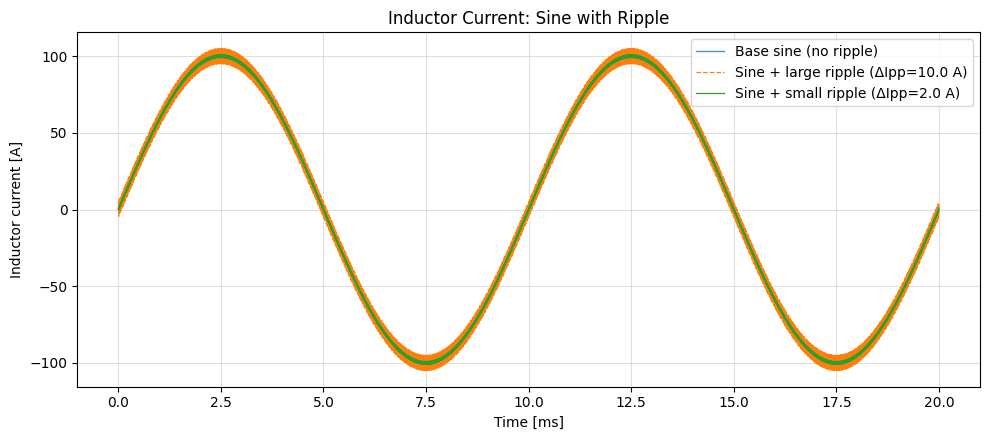

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# User parameters
# ----------------------------
I_peak = 100.0        # A, peak of fundamental sine current
f_fund = 100.0        # Hz, fundamental frequency
f_sw   = 50_000.0     # Hz, PWM switching frequency
DeltaIpp_small = 2.0  # A, small ripple peak-to-peak
DeltaIpp_large = 10.0 # A, large ripple peak-to-peak
cycles_to_show = 2    # number of sine cycles to plot

# ----------------------------
# Time base
# ----------------------------
T_fund = 1.0 / f_fund
t_end  = cycles_to_show * T_fund
fs     = int(max(40*f_sw, 1_000_000))  # high sampling rate
dt     = 1.0 / fs
t      = np.arange(0, t_end, dt)

# ----------------------------
# Generate triangle wave for ripple
# ----------------------------
T_sw = 1.0 / f_sw
phase = (t % T_sw) / T_sw
tri_unit = 4.0 * np.abs(phase - 0.5) - 1.0  # triangle in [-1,1]

# ----------------------------
# Build currents
# ----------------------------
i_sine = I_peak * np.sin(2*np.pi*f_fund*t)

i_small = i_sine + (DeltaIpp_small/2.0) * tri_unit
i_large = i_sine + (DeltaIpp_large/2.0) * tri_unit

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(10,4.5))
plt.plot(t*1e3, i_sine, label="Base sine (no ripple)", linewidth=1.0, alpha=0.8)
plt.plot(t*1e3, i_large, label=f"Sine + large ripple (ΔIpp={DeltaIpp_large} A)", linewidth=0.9, linestyle="--")
plt.plot(t*1e3, i_small, label=f"Sine + small ripple (ΔIpp={DeltaIpp_small} A)", linewidth=0.9)
plt.xlabel("Time [ms]")
plt.ylabel("Inductor current [A]")
plt.title("Inductor Current: Sine with Ripple")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


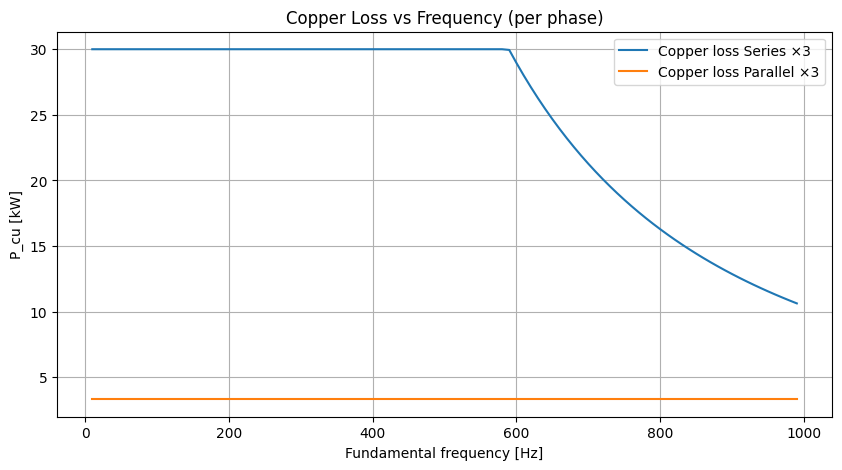

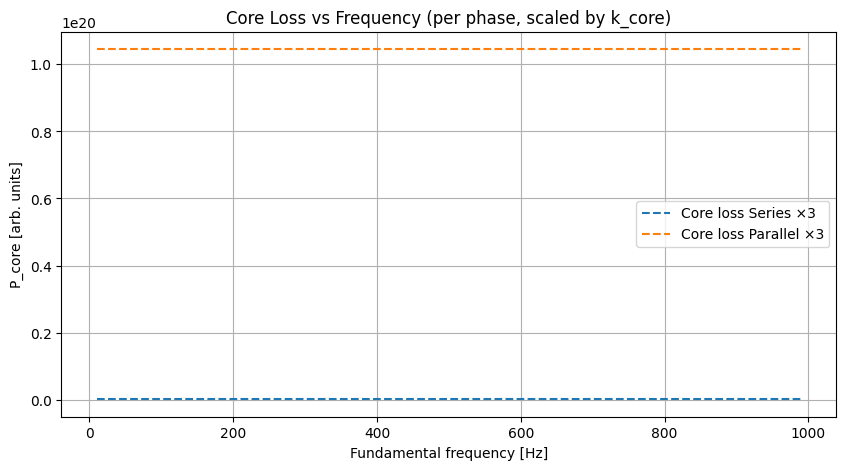

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Parameters
# ----------------------------
UDC = 100.0      # V, DC bus
Imax = 200.0     # A, current limit
f_range = np.arange(10, 1000, 10)  # Hz fundamental
fsw = 10e3      # Hz switching frequency
R_single = 0.25  # Ohm per inductor winding

# Inductor L(I) linear model (µH)
L0 = 150.0
Lmin = 45.0
Imax_data = 190.0
kL = (L0 - Lmin) / Imax_data

def L_single(I):
    """Single inductor L(I) [H] from datasheet linear approx"""
    L_uH = np.clip(L0 - kL*I, Lmin, L0)
    return L_uH * 1e-6

# Effective inductance functions
def L_series(I):   # 3 inductors in series
    return 3 * L_single(I)

def L_parallel(I): # 3 inductors in parallel
    return L_single(I/3) / 3

# Steinmetz parameters (ballpark ferrite values)
alpha = 1.5
beta = 2.6
k_core = 1.0e-3  # arbitrary scaling constant for visibility

# ----------------------------
# Compute loop
# ----------------------------
def compute_losses(L_func, config="series"):
    Pcu, Pcore = [], []
    for f in f_range:
        w = 2*np.pi*f
        # Conservative: evaluate L at Imax
        Ltot = L_func(Imax)
        
        # Inductor-limited current (reactive edge)
        I_reac_L = UDC / (w * Ltot)
        I = min(Imax, I_reac_L)
        
        # Copper losses
        if config=="series":
            Rtot = 3 * R_single
        else:  # parallel
            Rtot = R_single/3
        Pcu.append(Rtot * I**2 / 1e3)  # kW

        # Ripple and core losses
        DeltaIpp = UDC / (2*Ltot*fsw)
        Pcore.append(k_core * (fsw**alpha) * ((DeltaIpp/Ltot)**beta))
    return np.array(Pcu), np.array(Pcore)

Pcu_ser, Pcore_ser = compute_losses(L_series, "series")
Pcu_par, Pcore_par = compute_losses(L_parallel, "parallel")

# ----------------------------
# Plot results
# ----------------------------
plt.figure(figsize=(10,5))
plt.plot(f_range, Pcu_ser, label="Copper loss Series ×3", color="C0")
plt.plot(f_range, Pcu_par, label="Copper loss Parallel ×3", color="C1")
plt.title("Copper Loss vs Frequency (per phase)")
plt.xlabel("Fundamental frequency [Hz]")
plt.ylabel("P_cu [kW]")
plt.grid(True); plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(f_range, Pcore_ser, label="Core loss Series ×3", color="C0", linestyle="--")
plt.plot(f_range, Pcore_par, label="Core loss Parallel ×3", color="C1", linestyle="--")
plt.title("Core Loss vs Frequency (per phase, scaled by k_core)")
plt.xlabel("Fundamental frequency [Hz]")
plt.ylabel("P_core [arb. units]")
plt.grid(True); plt.legend()
plt.show()
